## Imports


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Sector mapping (SBI → naam)
sector_namen = {
    'A': 'Landbouw, bosbouw en visserij',
    'B': 'Delfstoffen',
    'C': 'Industrie',
    'D': 'Energie',
    'E': 'Water & afval',
    'F': 'Bouwnijverheid',
    'G': 'Groot- en detailhandel; reparatie van auto’s',
    'H': 'Vervoer en opslag',
    'I': 'Horeca',
    'J': 'Informatie & communicatie',
    'K': 'Financieel instellingen',
    'L': 'Vastgoed',
    'M': 'Zakelijke dienstverlening',
    'N': 'Overige zakelijke diensten',
    'O': 'Overheid',
    'P': 'Onderwijs',
    'Q': 'Zorg',
    'R': 'Cultuur & recreatie',
    'S': 'Overige dienstverlening'
}



# 1. Business Understanding 

In dit onderdeel van het onderzoek wordt de ontwikkeling van werkgelegenheid per sector in de provincie Flevoland geanalyseerd. Door inzicht te krijgen in hoe sectoren zich in de afgelopen jaren hebben ontwikkeld, kan beter worden begrepen welke sectoren groeien, stabiel blijven of juist krimpen.

Deze analyse is relevant voor de provincie Flevoland, omdat veranderingen in werkgelegenheid direct invloed hebben op economische ontwikkeling, arbeidsmarktbeleid en toekomstige investeringen.

---

## Doelstelling

Het doel van deze analyse is om structurele trends in werkgelegenheid per sector te identificeren. Hierbij wordt onderzocht welke sectoren over een langere periode groeien, stabiel blijven of krimpen.

Deze inzichten vormen de basis voor het opstellen van een betrouwbare prognose van de werkgelegenheid in Flevoland voor de komende 10 jaar.

---

## Onderzoeksvraag (Deelvraag 2)

> Welke sectoren laten structurele groei, stabiliteit of krimp zien in de historische werkgelegenheidsdata van Flevoland?

---

## Afbakening en definities

Om de analyse gericht en consistent uit te voeren, zijn de volgende keuzes gemaakt:

- **Targetvariabele:**  
  `wp` (werkzame personen), als maat voor de omvang van werkgelegenheid.

- **Sectorindeling:**  
  Op basis van `sector_code`, vertaald naar leesbare sectornamen.  
  (SBI-codes worden alleen gebruikt als aanvullende informatie.)

- **Regio:**  
  De analyse richt zich uitsluitend op de provincie Flevoland, gefilterd op `gemeente_code`.

- **Tijdsperiode:**  
  De periode 2014–2024, om zowel lange termijn trends als recente ontwikkelingen mee te nemen.

- **Dynamiek:**  
  De ontwikkeling van werkgelegenheid wordt gemeten aan de hand van relatieve groeimaten, zoals de gemiddelde jaarlijkse groei (CAGR). Hiermee kan structurele groei of krimp worden bepaald.

---

## Verwacht resultaat

De analyse leidt tot een overzicht van sectoren die worden ingedeeld in groei, stabiliteit of krimp. Daarnaast worden visuele analyses gebruikt om trends inzichtelijk te maken.

Dit resultaat maakt het mogelijk om economische verschuivingen binnen Flevoland te identificeren en vormt een belangrijke input voor verdere modellering en beleidsadvies.

<br></br>

# Data Understanding
---

### Onderbouwing
In deze stap laad ik de dataset in en voer ik een eerste verkenning uit om inzicht te krijgen in de structuur en inhoud van de data. Ik controleer het aantal rijen en kolommen om een beeld te krijgen van de omvang van de dataset. Daarnaast bekijk ik de kolomnamen om te bepalen welke variabelen beschikbaar zijn voor de analyse.

Vervolgens toon ik de eerste rijen van de dataset om te begrijpen hoe de data is opgebouwd en hoe de waarden eruitzien. Op basis van deze verkenning kan ik gericht bepalen welke variabelen relevant zijn voor het analyseren van de werkgelegenheid per sector.

In [4]:
# Data inladen
df = pd.read_excel('../../Data/raw/dataset.xlsx')
print(df.columns.tolist())

print(df.shape)
print(df.columns)
df.head()

['vestnr', 'postcode', 'plaats', 'gemeente_code', 'datum_start', 'datum_einde', 'jaar', 'man_fte', 'vrouw_fte', 'man_pte', 'vrouw_pte', 'wp', 'sector_code', 'sbi_code', 'rechtsvorm', 'rechtsvorm_code', 'bagoppervlak']
(137714, 17)
Index(['vestnr', 'postcode', 'plaats', 'gemeente_code', 'datum_start',
       'datum_einde', 'jaar', 'man_fte', 'vrouw_fte', 'man_pte', 'vrouw_pte',
       'wp', 'sector_code', 'sbi_code', 'rechtsvorm', 'rechtsvorm_code',
       'bagoppervlak'],
      dtype='object')


,vestnr,postcode,plaats,gemeente_code,datum_start,datum_einde,jaar,man_fte,vrouw_fte,man_pte,vrouw_pte,wp,sector_code,sbi_code,rechtsvorm,rechtsvorm_code,bagoppervlak
0,19593363327,3897LL,Zeewolde,50,2009-01-01 00:00:00,NaT,2015,2,2,0,0,4,A,1241,Besloten Vennootschap (BV),41.0,166.0
1,19593363327,3897LL,Zeewolde,50,2009-01-01 00:00:00,NaT,2016,1,1,0,0,2,A,1241,Besloten Vennootschap (BV),41.0,166.0
2,19593363327,3897LL,Zeewolde,50,2009-01-01 00:00:00,NaT,2017,1,1,0,0,2,A,1241,Besloten Vennootschap (BV),41.0,166.0
3,19593363327,3897LL,Zeewolde,50,2009-01-01 00:00:00,NaT,2018,1,1,0,0,2,A,1241,Besloten Vennootschap (BV),41.0,166.0
4,19593363327,3897LL,Zeewolde,50,2009-01-01 00:00:00,NaT,2019,1,1,0,0,2,A,1241,Besloten Vennootschap (BV),41.0,166.0



### Interpretatie
De dataset bevat 137.714 observaties en 17 variabelen. Elke rij vertegenwoordigt een vestiging in een bepaald jaar. Dit betekent dat dezelfde vestiging meerdere keren kan voorkomen in de dataset, namelijk voor verschillende jaren.

Belangrijke variabelen die opvallen:
- `jaar`: geeft het tijdselement van de data weer
- `wp`: het aantal werkzame personen (belangrijkste variabele voor deze analyse)
- `sector_code`: de sectorindeling van een vestiging
- `sbi_code`: meer gedetailleerde sectorinformatie
- `gemeente_code`: maakt het mogelijk om te filteren op Flevoland

De dataset lijkt geschikt voor tijdreeksanalyse, omdat meerdere jaren aanwezig zijn per vestiging.

### Koppeling aan deelvraag
Deze stap vormt de basis voor het beantwoorden van de deelvraag. Door inzicht te krijgen in de beschikbare variabelen kan worden bepaald hoe de werkgelegenheid per sector over de tijd kan worden geanalyseerd.

Met name de combinatie van `jaar`, `wp` en `sector_code` maakt het mogelijk om de ontwikkeling van werkgelegenheid per sector te onderzoeken en uiteindelijk vast te stellen welke sectoren groeien, stabiel blijven of krimpen.

---

### Onderbouwing
In deze stap controleer ik de kwaliteit van de dataset door te kijken naar de datatypes en het aantal ontbrekende waarden per variabele. Ik gebruik hiervoor de functies `df.info()` en `df.isna().sum()`.

Met `df.info()` controleer ik of de datatypes van de variabelen logisch zijn en of er geen onverwachte missende waarden aanwezig zijn. Vervolgens gebruik ik `df.isna().sum()` om per kolom inzicht te krijgen in het aantal ontbrekende waarden.

Deze controle is belangrijk om te bepalen of de dataset geschikt is voor verdere analyse en om te beslissen of aanvullende data cleaning nodig is.

In [5]:
df.info()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137714 entries, 0 to 137713
Data columns (total 17 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   vestnr           137714 non-null  int64         
 1   postcode         137714 non-null  object        
 2   plaats           137714 non-null  object        
 3   gemeente_code    137714 non-null  int64         
 4   datum_start      137714 non-null  object        
 5   datum_einde      29225 non-null   datetime64[ns]
 6   jaar             137714 non-null  int64         
 7   man_fte          137714 non-null  int64         
 8   vrouw_fte        137714 non-null  int64         
 9   man_pte          137714 non-null  int64         
 10  vrouw_pte        137714 non-null  int64         
 11  wp               137714 non-null  int64         
 12  sector_code      137714 non-null  object        
 13  sbi_code         137714 non-null  int64         
 14  rechtsvorm       137

vestnr                  0
postcode                0
plaats                  0
gemeente_code           0
datum_start             0
datum_einde        108489
jaar                    0
man_fte                 0
vrouw_fte               0
man_pte                 0
vrouw_pte               0
wp                      0
sector_code             0
sbi_code                0
rechtsvorm             10
rechtsvorm_code        10
bagoppervlak           85
dtype: int64

### Interpretatie
Uit de analyse blijkt dat de meeste variabelen volledig gevuld zijn en geen ontbrekende waarden bevatten. Met name de belangrijkste variabelen voor dit onderzoek, zoals `jaar`, `wp` en `sector_code`, zijn volledig compleet.

De kolom `datum_einde` bevat veel ontbrekende waarden. Dit is logisch, omdat veel vestigingen nog actief zijn en dus geen einddatum hebben. Deze kolom is daarom niet direct relevant voor de analyse.

Daarnaast bevatten de kolommen `rechtsvorm`, `rechtsvorm_code` en `bagoppervlak` een klein aantal ontbrekende waarden. Aangezien deze variabelen niet centraal staan in dit onderzoek, hebben deze missende waarden geen directe invloed op de analyse.

### Koppeling aan deelvraag
De controle op datakwaliteit laat zien dat de belangrijkste variabelen voor het analyseren van werkgelegenheid per sector volledig en betrouwbaar zijn. Hierdoor kan de dataset zonder grote aanpassingen worden gebruikt voor verdere analyse.

Dit betekent dat ik de ontwikkeling van werkgelegenheid per sector op een consistente manier kan onderzoeken, wat nodig is om te bepalen welke sectoren structurele groei, stabiliteit of krimp laten zien.

---

### Onderbouwing
In deze stap controleer ik of de dataset uitsluitend gegevens bevat van de provincie Flevoland. Hoewel de dataset al bedoeld is voor Flevoland, voer ik deze filtering uit als extra controle om zeker te zijn dat alleen de juiste gemeenten zijn opgenomen.

Daarnaast voeg ik een nieuwe kolom toe met leesbare sectornamen door de `sector_code` te mappen naar een duidelijke benaming. Dit maakt de verdere analyse en interpretatie overzichtelijker.

Vervolgens controleer ik welke jaren in de dataset aanwezig zijn en hoe de data over de jaren is verdeeld. Hiermee bepaal ik of de dataset geschikt is voor tijdreeksanalyse.

In [6]:
gemeentes_flevoland = [34, 303, 995, 171, 184, 50]
df_flevo = df[df['gemeente_code'].isin(gemeentes_flevoland)].copy()
df_flevo['Sector'] = df_flevo['sector_code'].map(sector_namen)
print(df_flevo.shape)
sorted(df_flevo['jaar'].unique())
df_flevo['jaar'].value_counts().sort_index()

(137714, 18)


jaar
2014    11907
2015    11568
2016    11484
2017    11445
2018    11671
2019    12701
2020    12935
2021    13240
2022    13596
2023    13515
2024    13652
Name: count, dtype: int64

### Interpretatie
Na filtering bevat de dataset uitsluitend gegevens van vestigingen in Flevoland. De verdeling over de jaren laat zien dat de dataset de periode 2014 tot en met 2024 omvat.

Het aantal observaties per jaar is redelijk stabiel, met een lichte toename in de latere jaren. Dit wijst erop dat de dataset consistent is opgebouwd en geschikt is om trends over de tijd te analyseren.

Daarnaast valt op dat de dataset ook de coronaperiode (2020–2021) bevat. Deze periode kan tijdelijke schommelingen in werkgelegenheid veroorzaken, met name in sectoren zoals horeca en dienstverlening. Dit betekent dat niet alle veranderingen in de data direct structureel van aard zijn.

De toevoeging van de sectornamen zorgt ervoor dat de data beter leesbaar is, wat de interpretatie van resultaten vergemakkelijkt.

### Koppeling aan deelvraag
Door de dataset te beperken tot Flevoland en te controleren dat meerdere jaren aanwezig zijn, kan ik de ontwikkeling van werkgelegenheid per sector over de tijd analyseren.

De aanwezigheid van een consistente tijdsperiode, inclusief de coronaperiode, maakt het mogelijk om structurele trends te identificeren. Tegelijkertijd moet bij de interpretatie rekening worden gehouden met tijdelijke schokken, zodat onderscheid kan worden gemaakt tussen structurele groei of krimp en kortetermijneffecten.

Dit is noodzakelijk om op een betrouwbare manier te bepalen welke sectoren structurele groei, stabiliteit of krimp laten zien.

---

### Onderbouwing
In deze stap bereken ik de totale werkgelegenheid per jaar door het aantal werkzame personen (`wp`) te aggregeren. Door de werkgelegenheid over de jaren heen op te tellen, krijg ik inzicht in de algemene ontwikkeling van de arbeidsmarkt in Flevoland.

Deze stap gebruik ik om te controleren of er sprake is van een stijgende, dalende of stabiele trend in de totale werkgelegenheid. Dit helpt om de context van de sectoranalyse beter te begrijpen.

In [7]:
df_flevo.groupby("jaar")["wp"].sum()

jaar
2014    146751
2015    146048
2016    147845
2017    149599
2018    154681
2019    160100
2020    159877
2021    162143
2022    166262
2023    169212
2024    172597
Name: wp, dtype: int64


### Interpretatie
De totale werkgelegenheid in Flevoland laat over de periode 2014–2024 een duidelijke stijgende trend zien. Het aantal werkzame personen neemt toe van ongeveer 146.000 in 2014 naar ruim 172.000 in 2024.

Rond 2020 is er een lichte stagnatie zichtbaar, wat mogelijk samenhangt met de coronaperiode. Na deze periode zet de groei weer door, wat wijst op herstel van de arbeidsmarkt.

Over het geheel genomen lijkt de werkgelegenheid in Flevoland structureel te groeien, met slechts beperkte tijdelijke schommelingen.

### Koppeling aan deelvraag
De algemene groei in werkgelegenheid vormt een belangrijke context voor de sectoranalyse. Omdat de totale werkgelegenheid toeneemt, is het waarschijnlijk dat meerdere sectoren bijdragen aan deze groei.

Door deze macrotrend in kaart te brengen, kan ik beter beoordelen of groei of krimp binnen sectoren onderdeel is van een bredere ontwikkeling of juist sectorspecifiek is. Dit helpt bij het bepalen welke sectoren structurele groei, stabiliteit of krimp laten zien.

---


### Onderbouwing
In deze stap analyseer ik de variabele `sbi_code` om inzicht te krijgen in de sectorindeling van de dataset. Ik bekijk het aantal unieke SBI-codes en de meest voorkomende codes.

Met deze analyse bepaal ik hoe gedetailleerd de sectorinformatie is en of deze direct bruikbaar is voor verdere analyse.

In [9]:
df_flevo['sbi_code'].nunique()
df_flevo['sbi_code'].value_counts().head(10)


sbi_code
111      3541
8891     2874
56102    2680
70221    2573
56101    2452
1134     2404
45112    2313
85201    2137
6201     2042
4120     2014
Name: count, dtype: int64

### Interpretatie
Uit de analyse blijkt dat de dataset een groot aantal verschillende SBI-codes bevat (794 unieke waarden). Dit betekent dat de sectorindeling zeer gedetailleerd is.

De meest voorkomende SBI-codes komen relatief vaak voor, maar het merendeel van de codes heeft een lage frequentie. Dit wijst op een sterk gefragmenteerde sectorindeling.

Door deze hoge mate van detail is de data in deze vorm minder geschikt voor directe analyse en interpretatie op sectorniveau.

### Koppeling aan deelvraag
Om de ontwikkeling van werkgelegenheid per sector te analyseren, is een overzichtelijke en consistente sectorindeling nodig. De huidige SBI-codes zijn hiervoor te gedetailleerd.

Daarom is het noodzakelijk om de SBI-codes in een volgende stap te groeperen naar hoofdsectoren. Dit maakt het mogelijk om trends per sector te analyseren en te bepalen welke sectoren structurele groei, stabiliteit of krimp laten zien.

---

### Onderbouwing
In deze stap controleer ik of de dataset dubbele rijen bevat. Ik gebruik hiervoor de functie `duplicated().sum()` om te bepalen of er identieke observaties in de data voorkomen.

Deze controle is belangrijk om te voorkomen dat bepaalde vestigingen dubbel worden meegeteld, wat de analyse van werkgelegenheid kan vertekenen.

In [10]:
df_flevo.duplicated().sum()

np.int64(0)

### Interpretatie
Uit de controle blijkt dat de dataset geen duplicaten bevat. Dit betekent dat elke rij een unieke observatie vertegenwoordigt en dat er geen sprake is van dubbele registratie van vestigingen binnen hetzelfde jaar.

Hierdoor kan de data betrouwbaar worden gebruikt voor verdere analyse zonder dat correcties nodig zijn voor dubbele waarden.

### Koppeling aan deelvraag
Doordat de dataset geen duplicaten bevat, kan de werkgelegenheid per sector op een correcte manier worden geaggregeerd. Dit is essentieel om betrouwbare trends te bepalen en vast te stellen welke sectoren structurele groei, stabiliteit of krimp laten zien.

---


### Onderbouwing
In deze stap analyseer ik de beschrijvende statistieken van de variabelen `jaar` en `wp`. Ik focus op deze variabelen omdat ze direct relevant zijn voor het analyseren van de ontwikkeling van werkgelegenheid over de tijd.

Met behulp van `describe()` krijg ik inzicht in de verdeling, spreiding en mogelijke uitschieters in de data. Dit helpt mij om de structuur van de werkgelegenheid beter te begrijpen voordat ik ga aggregeren per sector.

In [44]:
df_flevo[['jaar', 'wp']].describe()

,jaar,wp
count,137714.000000,137714.000000
mean,2019.201163,12.599409
std,3.169922,51.787143
min,2014.000000,2.000000
25%,2016.000000,2.000000
50%,2019.000000,3.000000
75%,2022.000000,8.000000
max,2024.000000,2785.000000


### Interpretatie
De variabele `jaar` loopt van 2014 tot en met 2024, wat bevestigt dat de dataset geschikt is voor tijdreeksanalyse.

Voor de variabele `wp` (werkzame personen) zie ik dat de mediaan 3 is en dat 75% van de vestigingen maximaal 8 werknemers heeft. Dit betekent dat het grootste deel van de bedrijven relatief klein is.

Tegelijkertijd is de maximale waarde 2785, wat wijst op de aanwezigheid van enkele grote werkgevers. Dit zorgt voor een scheve verdeling van de data, waarbij een klein aantal grote bedrijven een relatief groot aandeel heeft in de totale werkgelegenheid.

### Koppeling aan deelvraag
De scheve verdeling van werkgelegenheid betekent dat de totale werkgelegenheid per sector wordt beïnvloed door zowel veel kleine bedrijven als enkele grote werkgevers.

Dit is belangrijk bij het analyseren van sectorale trends, omdat groei of krimp in een sector deels kan worden veroorzaakt door veranderingen bij grotere bedrijven. Deze context neem ik mee bij het bepalen welke sectoren structurele groei, stabiliteit of krimp laten zien.

---

### Onderbouwing
In deze stap visualiseer ik de ontwikkeling van werkgelegenheid per sector over de tijd. Ik selecteer eerst de grootste sectoren op basis van totale werkgelegenheid (`wp`) om te focussen op de sectoren met de meeste impact.

Vervolgens groepeer ik de data per jaar en per sector en bereken ik het totaal aantal werkzame personen. Met behulp van een lijngrafiek breng ik de ontwikkeling van deze sectoren van 2014 tot en met 2024 in beeld.

Ik kies bewust voor een lijngrafiek, omdat deze geschikt is om veranderingen over de tijd inzichtelijk te maken. Hierdoor worden trends, groei en eventuele schommelingen per sector duidelijk zichtbaar en kunnen sectoren onderling goed met elkaar worden vergeleken.

De visualisatie richt zich op de grootste sectoren om de belangrijkste trends inzichtelijk te maken. Kleinere sectoren worden in deze grafiek buiten beschouwing gelaten om ruis te voorkomen. Deze sectoren worden later wel meegenomen in de analyse van sectorale dynamiek.

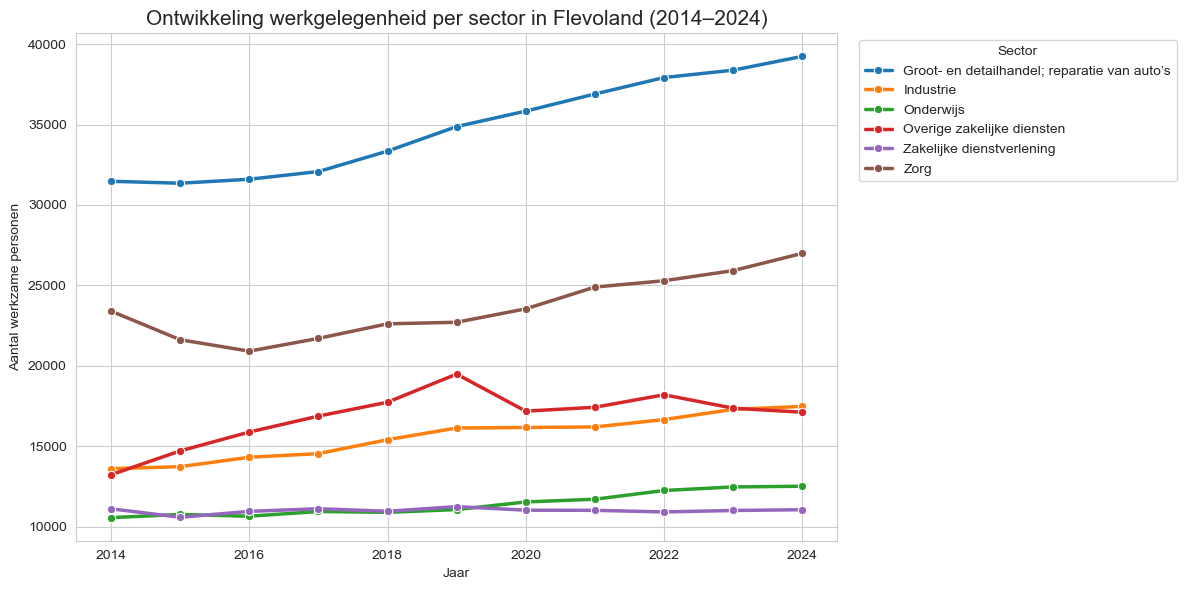

In [12]:
# Top sectoren bepalen
top_sectoren = (
    df_flevo.groupby('sector_code')['wp']
    .sum()
    .sort_values(ascending=False)
    .head(6)
    .index
)

# Filter dataset
df_top_sectoren = df_flevo[df_flevo['sector_code'].isin(top_sectoren)]

# Groeperen (NU MET Sector)
df_plot = df_top_sectoren.groupby(['jaar', 'Sector'])['wp'].sum().reset_index()

# Plot
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

sns.lineplot(
    data=df_plot,
    x='jaar',
    y='wp',
    hue='Sector',
    marker='o',
    linewidth=2.5
)

plt.title('Ontwikkeling werkgelegenheid per sector in Flevoland (2014–2024)', fontsize=15)
plt.xlabel('Jaar')
plt.ylabel('Aantal werkzame personen')

plt.legend(title='Sector', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

### Interpretatie
Uit de grafiek blijkt dat de meeste grote sectoren in Flevoland een stijgende trend laten zien in werkgelegenheid.

De sector **groot- en detailhandel** is duidelijk de grootste en laat een consistente groei zien over de gehele periode. Ook de sector **zorg** vertoont een duidelijke stijgende trend, met een lichte dip rond 2015–2016 en daarna een sterke groei.

De sector **industrie** groeit geleidelijk en stabiel, zonder grote schommelingen. De sector **onderwijs** laat een lichte maar constante groei zien.

De sector **overige zakelijke diensten** vertoont meer schommelingen, met een piek rond 2019 en een lichte daling daarna, mogelijk beïnvloed door externe factoren zoals de coronaperiode.

De sector **zakelijke dienstverlening** blijft relatief stabiel over de tijd, met slechts kleine veranderingen.

### Koppeling aan deelvraag
Deze visualisatie geeft een eerste inzicht in welke sectoren groeien, stabiel blijven of schommelingen vertonen.

De duidelijke groei in sectoren zoals handel en zorg wijst op structurele groei, terwijl sectoren zoals zakelijke dienstverlening meer stabiliteit laten zien. Sectoren met zichtbare schommelingen vereisen nadere analyse om te bepalen of deze veranderingen structureel of tijdelijk zijn.

Deze inzichten vormen een belangrijke basis voor het beantwoorden van de deelvraag, waarin wordt onderzocht welke sectoren structurele groei, stabiliteit of krimp laten zien.

---

### Onderbouwing
In deze stap analyseer ik de totale werkgelegenheid per sector over de gehele periode. Ik groepeer de data op basis van `Sector` en tel het aantal werkzame personen (`wp`) op.

Vervolgens visualiseer ik deze verdeling met een horizontale staafdiagram. Door de sectoren te sorteren op totale werkgelegenheid krijg ik een duidelijk beeld van welke sectoren het grootst zijn binnen Flevoland.

Ik kies bewust voor een horizontale staafdiagram, omdat deze geschikt is om verschillen tussen categorieën (sectoren) overzichtelijk te vergelijken. Daarnaast zorgt deze weergave ervoor dat lange sectornamen goed leesbaar blijven en de rangorde van sectoren direct zichtbaar is.

Deze analyse helpt om de relatieve omvang van sectoren te begrijpen voordat ik de ontwikkeling over de tijd verder analyseer.

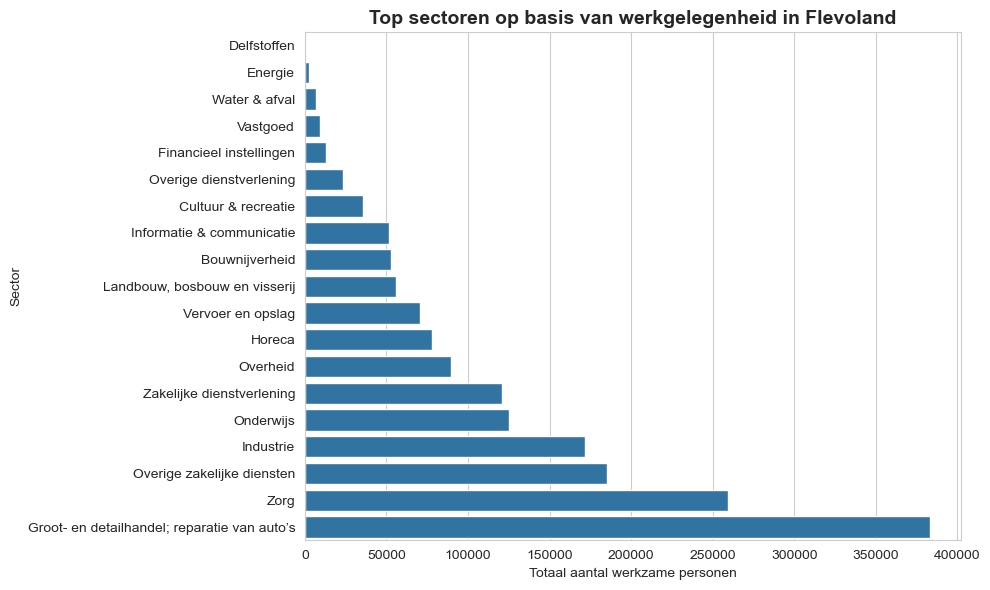

In [13]:
# Data voorbereiden
df_sector_total = df_flevo.groupby('Sector')['wp'].sum().sort_values(ascending=True)

# Plot
plt.figure(figsize=(10,6))
sns.set_style("whitegrid")

sns.barplot(
    x=df_sector_total.values,
    y=df_sector_total.index,
)

plt.title('Top sectoren op basis van werkgelegenheid in Flevoland', fontsize=14, weight='bold')
plt.xlabel('Totaal aantal werkzame personen')
plt.ylabel('Sector')

plt.tight_layout()
plt.show()

### Interpretatie
Uit de grafiek blijkt dat de sector **groot- en detailhandel; reparatie van auto’s** veruit de grootste sector is in Flevoland, gevolgd door de sector **zorg** en **overige zakelijke diensten**.

Daarnaast zijn sectoren zoals **industrie**, **onderwijs** en **zakelijke dienstverlening** ook relatief groot, terwijl sectoren zoals **energie**, **delfstoffen** en **water & afval** een zeer klein aandeel hebben in de totale werkgelegenheid.

Dit laat zien dat de werkgelegenheid in Flevoland sterk geconcentreerd is in een aantal grote sectoren, terwijl veel andere sectoren een beperkte omvang hebben.

### Koppeling aan deelvraag
De verschillen in omvang tussen sectoren zijn belangrijk bij het interpreteren van groei of krimp. Veranderingen in grote sectoren hebben namelijk meer invloed op de totale werkgelegenheid dan veranderingen in kleine sectoren.

Door inzicht te krijgen in welke sectoren dominant zijn, kan ik beter beoordelen welke trends daadwerkelijk relevant zijn voor de economische ontwikkeling van Flevoland. Dit helpt bij het bepalen welke sectoren structurele groei, stabiliteit of krimp laten zien.

---

# Data Cleaning – Opschonen en voorbereiden van de dataset


### Onderbouwing
In deze stap bereid ik de dataset voor op verdere analyse door alleen de relevante variabelen te selecteren en de data op te schonen.

Ik selecteer de kolommen `jaar`, `sector_code`, `sbi_code` en `wp`, omdat deze direct nodig zijn voor het analyseren van werkgelegenheid per sector over de tijd.

Vervolgens verwijder ik eventuele ontbrekende waarden in de kernvariabelen om te voorkomen dat deze de analyse beïnvloeden. Daarna zorg ik ervoor dat de datatypes correct zijn, zodat berekeningen en aggregaties betrouwbaar kunnen worden uitgevoerd.

Daarnaast voeg ik een nieuwe kolom toe met leesbare sectornamen door de `sector_code` te mappen naar een duidelijke benaming. Dit maakt de interpretatie van de resultaten overzichtelijker.

Tot slot verwijder ik eventuele rijen waarbij geen geldige sectornaam beschikbaar is, zodat alleen consistente en bruikbare data overblijft.

In [ ]:
# Selecteer alleen relevante kolommen
df_clean = df_flevo[['jaar', 'sector_code', 'sbi_code', 'wp']].copy()

# Verwijder eventuele missende waarden in kernkolommen
df_clean = df_clean.dropna(subset=['jaar', 'sector_code', 'wp'])

# 3. Zorg voor juiste datatypes
df_clean['jaar'] = df_clean['jaar'].astype(int)
df_clean['sector_code'] = df_clean['sector_code'].astype(str).str.strip()
df_clean['sbi_code'] = df_clean['sbi_code'].astype(str).str.strip()
df_clean['wp'] = df_clean['wp'].astype(int)

# 4. Voeg sectornamen toe (mapping heb je al bovenaan staan!)
df_clean['sector_naam'] = df_clean['sector_code'].map(sector_namen)

# 5. Verwijder eventuele onbekende sectoren
df_clean = df_clean.dropna(subset=['sector_naam'])

# 6. Controle
print("Aantal rijen na cleaning:", df_clean.shape[0])
display(df_clean.head())

Aantal rijen na cleaning: 137714


,jaar,sector_code,sbi_code,wp,sector_naam
0,2015,A,1241,4,"Landbouw, bosbouw en visserij"
1,2016,A,1241,2,"Landbouw, bosbouw en visserij"
2,2017,A,1241,2,"Landbouw, bosbouw en visserij"
3,2018,A,1241,2,"Landbouw, bosbouw en visserij"
4,2019,A,1241,2,"Landbouw, bosbouw en visserij"


### Interpretatie
Na het opschonen bevat de dataset nog steeds 137.714 observaties, wat aangeeft dat er geen significante dataverlies heeft plaatsgevonden tijdens de cleaning.

De dataset bestaat nu uit een compacte en consistente set variabelen die direct relevant zijn voor de analyse. De toevoeging van de sectornamen maakt de data beter interpreteerbaar en geschikt voor visualisaties en verdere aggregaties.

### Koppeling aan deelvraag
Door de dataset op te schonen en te focussen op de relevante variabelen, kan ik de werkgelegenheid per sector op een betrouwbare manier analyseren.

Deze stap zorgt ervoor dat de verdere berekeningen en analyses gebaseerd zijn op consistente en correcte data, wat essentieel is om te bepalen welke sectoren structurele groei, stabiliteit of krimp laten zien.

---

### Onderbouwing
In deze stap aggregeer ik de werkgelegenheid per sector en per jaar. Ik groepeer de dataset op basis van `jaar` en `sector_naam` en tel het aantal werkzame personen (`wp`) op.

Vervolgens zet ik deze gegroepeerde data om in een pivot table, waarbij de jaren als rijen worden weergegeven en de sectoren als kolommen. Hierdoor ontstaat een overzichtelijke tijdreeks per sector.

Daarnaast sorteer ik de sectoren op basis van totale werkgelegenheid, zodat de grootste sectoren als eerste zichtbaar zijn. Dit maakt de analyse overzichtelijker en helpt om de belangrijkste sectoren sneller te identificeren.

In [ ]:
# alle werkzame personen optellen per jaar en per sector
sector_jaar_totaal = df_clean.groupby(['jaar', 'sector_naam'])['wp'].sum().reset_index()

# 2. Pivot table: jaren als rijen, sectoren als kolommen
pivot_df = sector_jaar_totaal.pivot(index='jaar', columns='sector_naam', values='wp').fillna(0)
pivot_df = pivot_df[pivot_df.sum().sort_values(ascending=False).index]
# 3. Resultaat laten zien
display(pivot_df)
pivot_df.shape

sector_naam,Groot- en detailhandel; reparatie van auto’s,Zorg,Overige zakelijke diensten,Industrie,Onderwijs,Zakelijke dienstverlening,Overheid,Horeca,Vervoer en opslag,"Landbouw, bosbouw en visserij",Bouwnijverheid,Informatie & communicatie,Cultuur & recreatie,Overige dienstverlening,Financieel instellingen,Vastgoed,Water & afval,Energie,Delfstoffen
jaar,,,,,,,,,,,,,,,,,,,
2014,31475.0,23405.0,13229.0,13606.0,10561.0,11113.0,8067.0,5951.0,6132.0,5053.0,4260.0,6061.0,3032.0,1739.0,1557.0,748.0,507.0,251.0,4.0
2015,31354.0,21624.0,14710.0,13731.0,10761.0,10585.0,8114.0,6252.0,6118.0,4891.0,4060.0,6007.0,2970.0,1814.0,1520.0,759.0,526.0,250.0,2.0
2016,31601.0,20913.0,15884.0,14316.0,10650.0,10952.0,8022.0,6351.0,5942.0,4851.0,4186.0,6288.0,3055.0,1834.0,1481.0,748.0,532.0,237.0,2.0
2017,32079.0,21706.0,16874.0,14543.0,10945.0,11116.0,7836.0,7012.0,5819.0,4864.0,4448.0,4321.0,3206.0,1930.0,1367.0,768.0,544.0,219.0,2.0
2018,33348.0,22612.0,17739.0,15409.0,10891.0,10959.0,7761.0,7411.0,6358.0,5090.0,4733.0,4328.0,3192.0,2181.0,1033.0,819.0,594.0,223.0,0.0
2019,34876.0,22709.0,19487.0,16136.0,11064.0,11247.0,7732.0,7951.0,6314.0,5307.0,4852.0,4003.0,3419.0,2151.0,1085.0,851.0,682.0,227.0,7.0
2020,35836.0,23544.0,17183.0,16167.0,11538.0,11026.0,8106.0,7500.0,6297.0,5326.0,5028.0,3922.0,3414.0,2151.0,1087.0,891.0,698.0,160.0,3.0
2021,36901.0,24898.0,17425.0,16201.0,11707.0,11017.0,8103.0,7072.0,6543.0,5296.0,5008.0,4000.0,2961.0,2253.0,1030.0,875.0,690.0,161.0,2.0
2022,37923.0,25290.0,18202.0,16658.0,12250.0,10916.0,8266.0,7345.0,6819.0,5113.0,5140.0,4103.0,3147.0,2276.0,959.0,880.0,695.0,280.0,0.0


(11, 19)

### Interpretatie
De pivot table laat zien hoe de werkgelegenheid zich per sector heeft ontwikkeld over de periode 2014–2024.

Opvallend is dat sectoren zoals **groot- en detailhandel**, **zorg** en **overige zakelijke diensten** structureel tot de grootste sectoren behoren. Deze sectoren laten over de tijd een duidelijke groei zien.

Daarnaast zijn er sectoren zoals **industrie**, **onderwijs** en **bouwnijverheid** die een meer geleidelijke groei laten zien.

Ook valt op dat kleinere sectoren, zoals **energie**, **water & afval** en **delfstoffen**, een zeer beperkte omvang hebben en soms weinig verandering laten zien. Hierdoor kunnen procentuele veranderingen in deze sectoren relatief groot lijken, terwijl de absolute impact klein is.

De tabel laat bovendien zien dat sommige sectoren tijdelijke schommelingen vertonen, bijvoorbeeld rond de coronaperiode (2020–2021), wat kan duiden op externe invloeden in plaats van structurele veranderingen.

### Koppeling aan deelvraag
Deze aggregatie vormt de basis voor het analyseren van sectorale dynamiek. Doordat de werkgelegenheid per sector en per jaar inzichtelijk is gemaakt, kan ik de ontwikkeling van sectoren over de tijd volgen.

Op basis van deze gegevens kan ik in de volgende stap berekenen welke sectoren structurele groei, stabiliteit of krimp laten zien. Dit is direct nodig om de deelvraag te beantwoorden.

---

### Onderbouwing
In deze stap bereken ik de dynamiek van werkgelegenheid per sector over de periode 2014–2024. Ik gebruik hiervoor de geaggregeerde data uit de vorige stap.

Allereerst bereken ik de absolute groei en de totale procentuele groei per sector. Vervolgens bereken ik de gemiddelde jaarlijkse groei (CAGR), omdat deze maat een beter beeld geeft van structurele ontwikkeling over meerdere jaren.

Daarnaast filter ik sectoren met minder dan 1000 werkzame personen in 2014. Kleine sectoren kunnen namelijk extreme procentuele veranderingen laten zien, terwijl de absolute impact beperkt is.

Door deze sectoren buiten beschouwing te laten, voorkom ik dat de analyse wordt vertekend en kan ik mij richten op sectoren die daadwerkelijk relevant zijn voor de economische ontwikkeling van Flevoland.

Om de sectoren te classificeren, deel ik de CAGR in drie categorieën:
- Groei: CAGR > 2%
- Krimp: CAGR < -1%
- Stabiel: tussen -1% en 2%

Deze grenzen zijn gekozen om onderscheid te maken tussen duidelijke structurele veranderingen en normale schommelingen in de data. Kleine fluctuaties rond 0% worden hierbij als stabiel beschouwd.

In [16]:
# Aantal jaren (2014 → 2024)
n_jaar = 2024 - 2014

# Dynamiek berekenen
summary_df = pd.DataFrame({
    'WP_2014': pivot_df.loc[2014],
    'WP_2024': pivot_df.loc[2024]
})

# Absolute groei
summary_df['Verschil_Absoluut'] = summary_df['WP_2024'] - summary_df['WP_2014']

# Totale groei (%)
summary_df['Totale_Groei_%'] = (
    (summary_df['Verschil_Absoluut'] / summary_df['WP_2014']) * 100
).round(2)

# CAGR (jaarlijkse groei)
summary_df['CAGR_%'] = (
    ((summary_df['WP_2024'] / summary_df['WP_2014']) ** (1 / n_jaar) - 1) * 100
).round(2)

summary_df = summary_df.replace([np.inf, -np.inf], np.nan)

# kleine sectoren filteren (belangrijk!)
summary_df = summary_df[summary_df['WP_2014'] > 1000]

# NaN verwijderen
summary_df = summary_df.dropna()

# Gemiddelde omvang toevoegen
summary_df['Gemiddelde_omvang'] = (
    summary_df['WP_2014'] + summary_df['WP_2024']
) / 2

def classify(cagr):
    if cagr > 2:
        return 'Groei'
    elif cagr < -1:
        return 'Krimp'
    else:
        return 'Stabiel'

summary_df['Dynamiek'] = summary_df['CAGR_%'].apply(classify)

summary_df = summary_df.sort_values(by='CAGR_%', ascending=False)

display(summary_df)

,WP_2014,WP_2024,Verschil_Absoluut,Totale_Groei_%,CAGR_%,Gemiddelde_omvang,Dynamiek
sector_naam,,,,,,,
Overige dienstverlening,1739.0,2456.0,717.0,41.23,3.51,2097.5,Groei
Bouwnijverheid,4260.0,5706.0,1446.0,33.94,2.97,4983.0,Groei
Horeca,5951.0,7765.0,1814.0,30.48,2.70,6858.0,Groei
Overige zakelijke diensten,13229.0,17116.0,3887.0,29.38,2.61,15172.5,Groei
Industrie,13606.0,17479.0,3873.0,28.47,2.54,15542.5,Groei
Groot- en detailhandel; reparatie van auto’s,31475.0,39239.0,7764.0,24.67,2.23,35357.0,Groei
Cultuur & recreatie,3032.0,3694.0,662.0,21.83,1.99,3363.0,Stabiel
Onderwijs,10561.0,12515.0,1954.0,18.50,1.71,11538.0,Stabiel
Vervoer en opslag,6132.0,7268.0,1136.0,18.53,1.71,6700.0,Stabiel


### Interpretatie
Uit de resultaten blijkt dat meerdere sectoren een duidelijke structurele groei laten zien. Met name **overige dienstverlening**, **bouwnijverheid**, **horeca**, **overige zakelijke diensten**, **industrie** en **handel** groeien gemiddeld met meer dan 2% per jaar.

Daarnaast zijn er sectoren die relatief stabiel blijven, zoals **onderwijs**, **zorg** en **overheid**, met een gematigde groei tussen ongeveer 1% en 2% per jaar.

Tegelijkertijd laten enkele sectoren duidelijke krimp zien. Vooral **financiële instellingen** en **informatie & communicatie** vertonen een negatieve groei over de gehele periode. Bij deze sectoren is sprake van een afname in werkgelegenheid.

De resultaten laten ook zien dat kleinere sectoren sneller extreme percentages kunnen laten zien, wat de reden is dat deze deels zijn gefilterd.

### Koppeling aan deelvraag
Op basis van de berekende CAGR en de classificatie kan worden vastgesteld welke sectoren structurele groei, stabiliteit of krimp laten zien in Flevoland.

De analyse laat zien dat de economische groei in Flevoland vooral wordt gedragen door sectoren zoals handel, industrie en zakelijke dienstverlening. Tegelijkertijd zijn er sectoren die stabiel blijven en sectoren die structureel krimpen.

Hiermee wordt de deelvraag beantwoord: er zijn duidelijke verschillen in ontwikkeling tussen sectoren, waarbij sommige sectoren structureel groeien, andere stabiel blijven en enkele sectoren krimp vertonen.

---

## Visualisatie – Sectorale dynamiek (CAGR)

### Onderbouwing
In deze stap visualiseer ik de sectorale dynamiek op basis van de gemiddelde jaarlijkse groei (CAGR) per sector over de periode 2014–2024.

Ik kies voor een horizontale staafdiagram, omdat deze geschikt is om verschillen tussen categorieën (sectoren) duidelijk te vergelijken. Door de sectoren te sorteren op CAGR wordt direct zichtbaar welke sectoren het sterkst groeien en welke krimpen.

Daarnaast gebruik ik kleurcodering om de interpretatie te ondersteunen:
- groen voor groei (CAGR > 2%)
- rood voor krimp (CAGR < -1%)
- grijs voor stabiele sectoren

Ook voeg ik een verticale lijn op 0% toe, zodat het onderscheid tussen groei en krimp visueel duidelijk wordt.

Deze visualisatie maakt het mogelijk om in één overzicht de structurele ontwikkeling van alle relevante sectoren te analyseren en te vergelijken.

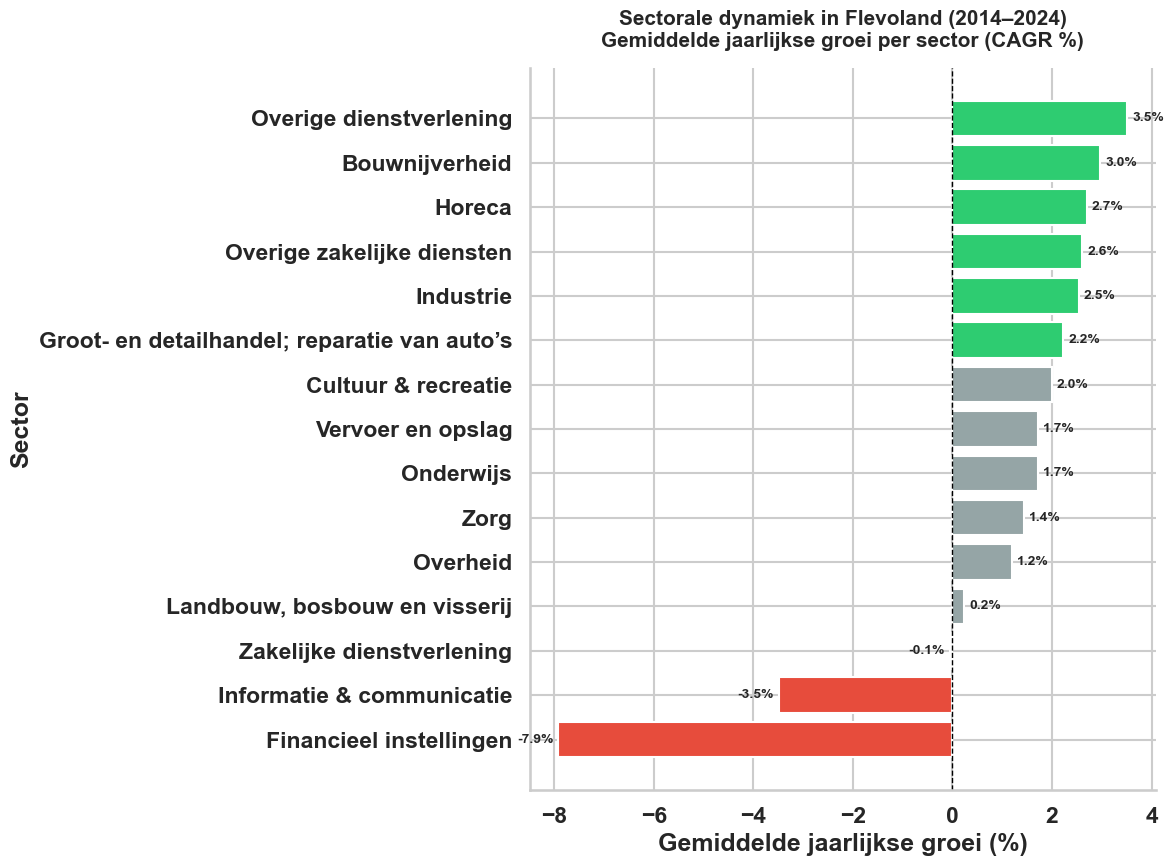

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({
    'font.weight': 'bold',
    'axes.titleweight': 'bold',
    'axes.labelweight': 'bold'
})

# Data voorbereiden
plot_data = summary_df.reset_index().sort_values('CAGR_%', ascending=True)

# Thema
sns.set_theme(style="whitegrid", context="talk")

# Kleuren bepalen
def kleur(cagr):
    if cagr > 2:
        return '#2ecc71'   # groei
    elif cagr < -1:
        return '#e74c3c'   # krimp
    else:
        return '#95a5a6'   # stabiel

colors = plot_data['CAGR_%'].apply(kleur)

# Plot
fig, ax = plt.subplots(figsize=(12, 9))

ax.barh(
    plot_data['sector_naam'],
    plot_data['CAGR_%'],
    color=colors
)

# Nul-lijn
ax.axvline(0, color='black', linestyle='--', linewidth=1)

# Titel en labels
ax.set_title(
    'Sectorale dynamiek in Flevoland (2014–2024)\nGemiddelde jaarlijkse groei per sector (CAGR %)',
    fontsize=15,
    fontweight='bold',
    pad=15
)
ax.set_xlabel('Gemiddelde jaarlijkse groei (%)')
ax.set_ylabel('Sector')

# Waarden op balken
for i, v in enumerate(plot_data['CAGR_%']):
    if v >= 0:
        ax.text(v + 0.1, i, f'{v:.1f}%', va='center', ha='left', fontsize=10)
    else:
        ax.text(v - 0.1, i, f'{v:.1f}%', va='center', ha='right', fontsize=10)

sns.despine()
plt.tight_layout()
plt.show()

### Interpretatie
De grafiek laat zien dat meerdere sectoren een duidelijke positieve groei kennen, zoals overige dienstverlening, bouwnijverheid en horeca. Deze sectoren groeien structureel met meer dan 2% per jaar.

Daarnaast zijn er sectoren die relatief stabiel blijven, zoals zorg, onderwijs en overheid, met een gematigde groei.

Tegelijkertijd zijn er sectoren die krimp laten zien, met name financieel instellingen en informatie & communicatie. Deze sectoren hebben een negatieve jaarlijkse groei over de periode.

### Koppeling aan deelvraag
Op basis van deze visualisatie kan worden vastgesteld welke sectoren structurele groei, stabiliteit of krimp laten zien. De verschillen tussen sectoren worden duidelijk zichtbaar, waardoor de sectorale dynamiek binnen Flevoland inzichtelijk wordt gemaakt.

---

## Conclusie – Sectorale dynamiek in Flevoland

Op basis van de analyse van werkgelegenheid per sector over de periode 2014–2024 kan worden geconcludeerd dat er duidelijke verschillen bestaan in de ontwikkeling van sectoren binnen Flevoland.

Uit de visualisatie van de gemiddelde jaarlijkse groei (CAGR) blijkt dat sectoren zoals **overige dienstverlening**, **bouwnijverheid**, **horeca**, **industrie** en **groot- en detailhandel** structurele groei laten zien. Deze sectoren groeien gemiddeld met meer dan 2% per jaar en dragen daarmee actief bij aan de toename van werkgelegenheid.

Daarnaast zijn er sectoren zoals **zorg**, **onderwijs**, **overheid** en **vervoer en opslag** die een stabiele ontwikkeling laten zien. Deze sectoren groeien wel, maar in een gematigder tempo en vormen daarmee een stabiele basis binnen de economie van Flevoland.

Tegelijkertijd zijn er sectoren die krimp vertonen, met name **financiële instellingen** en **informatie & communicatie**. Deze sectoren laten over de gehele periode een afname in werkgelegenheid zien, wat wijst op mogelijke structurele veranderingen.

Opvallend is dat deze sectoren relatief grote negatieve groeipercentages laten zien. Omdat deze percentages mogelijk worden beïnvloed door schommelingen in de data of veranderingen in registratie, zal in de validatiefase nader worden onderzocht of deze krimp daadwerkelijk structureel is of (gedeeltelijk) wordt veroorzaakt door datakwaliteit of externe factoren.

Wanneer deze resultaten worden vergeleken met de eerdere visualisatie van de grootste sectoren, valt op dat met name grote sectoren zoals **handel**, **zorg** en **industrie** niet alleen dominant zijn in omvang, maar ook een duidelijke groei laten zien. Dit betekent dat zij een belangrijke rol spelen in de economische ontwikkeling van Flevoland.

Daarentegen hebben kleinere sectoren, ondanks soms hoge groeipercentages, een beperkte invloed op de totale werkgelegenheid. Hierdoor is het belangrijk om zowel relatieve groei (CAGR) als absolute omvang mee te nemen in de analyse.

Concluderend kan worden gesteld dat de werkgelegenheid in Flevoland voornamelijk wordt gedreven door een aantal grote, groeiende sectoren, terwijl andere sectoren stabiel blijven of krimpen. Hiermee is de deelvraag beantwoord: er zijn duidelijke structurele verschillen in groei, stabiliteit en krimp tussen sectoren in Flevoland.

## Validatie – Analyse van sectoren met sterke krimp

### Onderbouwing
In deze stap controleer ik de sectoren met opvallend hoge negatieve groeipercentages, namelijk **informatie & communicatie** en **financiële instellingen**.

Ik selecteer deze sectoren specifiek uit de pivot table en bekijk de ontwikkeling van werkgelegenheid per jaar. Door de tijdreeks van deze sectoren afzonderlijk te analyseren, kan ik beoordelen of de berekende krimp daadwerkelijk structureel is of mogelijk wordt veroorzaakt door tijdelijke schommelingen of dataproblemen.

Deze validatiestap is belangrijk om te voorkomen dat conclusies worden getrokken op basis van vertekende of onbetrouwbare data.

In [18]:
pivot_df[['Informatie & communicatie', 'Financieel instellingen']]

sector_naam,Informatie & communicatie,Financieel instellingen
jaar,,
2014,6061.0,1557.0
2015,6007.0,1520.0
2016,6288.0,1481.0
2017,4321.0,1367.0
2018,4328.0,1033.0
2019,4003.0,1085.0
2020,3922.0,1087.0
2021,4000.0,1030.0
2022,4103.0,959.0


### Interpretatie
De sector **informatie & communicatie** laat een duidelijke daling zien tussen 2016 en 2017, waarbij het aantal werkzame personen sterk afneemt van ongeveer 6300 naar 4300. Na deze daling blijft de werkgelegenheid relatief stabiel rond de 4000–4300.

De sector **financiële instellingen** laat een meer geleidelijke maar consistente daling zien over de gehele periode, van ongeveer 1557 in 2014 naar 682 in 2024.

Deze patronen wijzen erop dat de krimp in financiële instellingen waarschijnlijk structureel is, terwijl de sterke daling in informatie & communicatie deels wordt veroorzaakt door een plotselinge breuk in de data rond 2017.

### Koppeling aan deelvraag
Deze validatie laat zien dat niet alle negatieve groeipercentages direct als structurele krimp geïnterpreteerd kunnen worden. In het geval van informatie & communicatie speelt waarschijnlijk een eenmalige daling een grote rol in het uiteindelijke groeipercentage.

Hierdoor is het belangrijk om naast de berekende CAGR ook de onderliggende tijdreeks te analyseren. Op basis van deze controle kan worden geconcludeerd dat de krimp in financiële instellingen waarschijnlijk structureel is, terwijl de krimp in informatie & communicatie met voorzichtigheid geïnterpreteerd moet worden.

Dit draagt bij aan een betrouwbaarder antwoord op de deelvraag, doordat onderscheid wordt gemaakt tussen structurele trends en mogelijke databreuken.

---

### Onderbouwing
In deze stap controleer ik sectoren met opvallende krimp, namelijk informatie & communicatie en financiële instellingen. Ik visualiseer de ontwikkeling van werkgelegenheid per jaar om te beoordelen of de berekende krimp structureel is.

Ik kies hierbij bewust voor een lijngrafiek, omdat deze geschikt is om veranderingen over de tijd inzichtelijk te maken. Een lijngrafiek maakt trends, breuken en schommelingen in de tijdreeks direct zichtbaar.

Hierdoor kan ik beoordelen of de krimp geleidelijk verloopt (structureel) of dat er sprake is van een plotselinge verandering, wat kan wijzen op externe invloeden of een mogelijke databreuk.

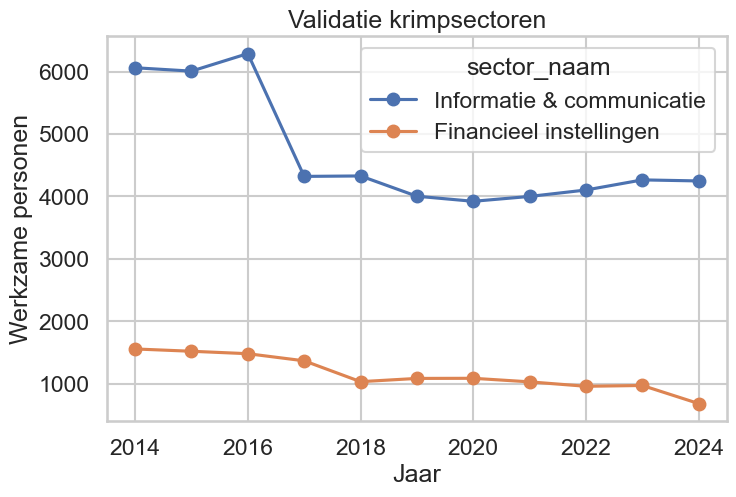

In [20]:
pivot_df[['Informatie & communicatie', 'Financieel instellingen']].plot(marker='o', figsize=(8,5))

plt.title('Validatie krimpsectoren')
plt.xlabel('Jaar')
plt.ylabel('Werkzame personen')
plt.grid(True)
plt.show()

### Interpretatie
De sector financiële instellingen laat een geleidelijke en consistente daling zien over de gehele periode.

De sector informatie & communicatie laat een sterke daling zien rond 2017, waarna de werkgelegenheid relatief stabiel blijft. Dit wijst mogelijk op een eenmalige verandering in plaats van een continue krimp.

### Conclusie validatie

Op basis van de visualisatie kan worden geconcludeerd dat de krimp in **financiële instellingen** consistent en geleidelijk verloopt over de gehele periode. Dit wijst op een structurele afname van werkgelegenheid binnen deze sector.

Voor **informatie & communicatie** is het beeld genuanceerder. De sterke daling tussen 2016 en 2017 heeft een grote invloed op de berekende groeipercentages. Na deze daling blijft de werkgelegenheid relatief stabiel, wat suggereert dat de krimp niet volledig structureel is, maar deels wordt veroorzaakt door een eenmalige verandering of databreuk.

Deze validatie laat zien dat het belangrijk is om naast samenvattende statistieken, zoals CAGR, ook de onderliggende tijdreeksen te analyseren. Hierdoor kan beter onderscheid worden gemaakt tussen structurele trends en tijdelijke schommelingen.

Op basis hiervan kan worden geconcludeerd dat de krimp in financiële instellingen als structureel kan worden beschouwd, terwijl de krimp in informatie & communicatie met voorzichtigheid geïnterpreteerd moet worden.

---

In [ ]:
# Bestanden opslaan voor de teamleider (Faysal)

# 1. De volledige trend-tabel (WP per sector per jaar)
pivot_df.to_excel('../../Data/processed/deelvraag2_sectorale_trends.xlsx')

# 2. De samenvatting met groeipercentages en CAGR
summary_df.to_excel('../../Data/processed/deelvraag2_groei_samenvatting.xlsx')


Bestanden succesvol opgeslagen! Je kunt deze nu naar Faysal sturen.
